# 1. Análise Analítica de Cavidade Ressonante Elíptica 3D (Modos TE e TM)

Este notebook calcula os parâmetros fundamentais de uma cavidade ressonante elíptica 3D, estrutura essencial na otimização de dispositivos de alta complexidade e precisão, como MASERs de estado sólido em temperatura ambiente. A geometria exige a mudança do sistema de coordenadas cartesianas para o sistema de coordenadas elípticas $(\xi, \eta, z)$.

A elipse base é definida pelo semi-eixo maior ($a$) e semi-eixo menor ($b$), estendida por um comprimento longitudinal ($d$). A distância focal $f$ é dada por $f = \sqrt{a^2 - b^2}$. A fronteira metálica ocorre na coordenada radial elíptica constante $\xi_0 = \text{acosh}(a/f)$ e nas extremidades $z = 0$ e $z = d$.

## 1.1 Frequências de Ressonância e Funções de Mathieu

As equações de onda na cavidade resultam nas **Funções de Mathieu** e em ondas estacionárias ao longo do eixo $z$. Os modos pares são denotados como $eTE_{mnp}$ e $eTM_{mnp}$:
* **$m$**: Ordem da função angular de Mathieu (variações azimutais).
* **$n$**: Índice da raiz da função radial modificada de Mathieu.
* **$p$**: Número de meias-ondas ao longo do comprimento da cavidade ($z$).

A componente transversal do número de onda ($k_c$) é governada pelo parâmetro estrutural $q = \left(\frac{k_c f}{2}\right)^2$. A raiz numérica deve garantir que:
* **Modos TM:** $Ce_m(\xi_0, q) = 0$
* **Modos TE:** $Ce'_m(\xi_0, q) = 0$

A frequência de ressonância tridimensional final é calculada associando o número de onda transversal $k_c$ e o número de onda longitudinal $k_z = \frac{p \pi}{d}$:
$$f_{mnp} = \frac{c}{2 \pi \sqrt{\epsilon_r}} \sqrt{k_c^2 + \left(\frac{p \pi}{d}\right)^2}$$

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy.constants as sc
import scipy.special as sp
import scipy.optimize as opt
from mpl_toolkits.mplot3d import Axes3D 

class CavidadeEliptica3D:
    def __init__(self, a, b, d, er=1.0):
        """
        Inicializa a cavidade elíptica 3D.
        a: Semi-eixo maior (em x)
        b: Semi-eixo menor (em y)
        d: Comprimento da cavidade (em z)
        """
        if b >= a:
            raise ValueError("O semi-eixo 'a' (x) deve ser estritamente maior que 'b' (y).")
            
        self.a = a
        self.b = b
        self.d = d
        self.er = er
        self.c = sc.c / np.sqrt(er)
        
        # Parâmetros focais da elipse
        self.f = np.sqrt(a**2 - b**2)
        self.xi_0 = np.arccosh(a / self.f)
        
    def _equacao_raizes(self, kc, m, tipo_modo):
        """Equação cujo zero determina o kc. Usa as funções de Mathieu."""
        q = (kc * self.f / 2)**2
        
        # sp.mathieu_modcem1 retorna: (valor_da_funcao, valor_da_derivada)
        ce_val, ce_der = sp.mathieu_modcem1(m, q, self.xi_0)
        
        if tipo_modo.upper() == 'TM':
            return ce_val  # TM exige que a função seja 0 na borda
        elif tipo_modo.upper() == 'TE':
            return ce_der  # TE exige que a derivada seja 0 na borda
        else:
            raise ValueError("Tipo deve ser 'TE' ou 'TM'")

    def k_c(self, m, n, tipo_modo):
        """Busca a n-ésima raiz da função de Mathieu para encontrar kc transversal."""
        # Chute inicial baseado em um círculo equivalente
        r_eq = (self.a + self.b) / 2.0
        kc_guess = sp.jn_zeros(m, n)[n-1] / r_eq if tipo_modo == 'TM' else sp.jnp_zeros(m, n)[n-1] / r_eq
        
        # Criamos um vetor de busca para "enlaçar" a raiz corretamente
        kcs = np.linspace(kc_guess * 0.5, kc_guess * 2.0, 500)
        valores = [self._equacao_raizes(k, m, tipo_modo) for k in kcs]
        
        # Detecta mudanças de sinal (onde a raiz cruza o zero)
        mudancas_sinal = np.where(np.diff(np.sign(valores)))[0]
        
        if len(mudancas_sinal) < n:
            raise RuntimeError("Não foi possível encontrar a raiz com a precisão atual.")
            
        idx_raiz = mudancas_sinal[n-1]
        
        # Refina a raiz encontrada usando o algoritmo de Brent
        kc_otimizado = opt.brentq(self._equacao_raizes, kcs[idx_raiz], kcs[idx_raiz+1], args=(m, tipo_modo))
        
        return kc_otimizado

    def freq_ressonancia(self, m, n, p, tipo_modo):
        """Frequência de ressonância 3D analítica para o modo eTE ou eTM."""
        kc = self.k_c(m, n, tipo_modo)
        kz = (p * np.pi) / self.d
        k_total = np.sqrt(kc**2 + kz**2)
        return (self.c / (2 * np.pi)) * k_total

print("Classe CavidadeEliptica3D (com funções de Mathieu e Solvers) carregada!")

Classe CavidadeEliptica3D (com funções de Mathieu e Solvers) carregada!


## 1.2 Distribuição do Campo na Cavidade

A distribuição espacial tridimensional dos modos pares (Even) depende das funções angulares e radiais modificadas de Mathieu, ponderadas pelas ondas estacionárias no comprimento $d$.

* **Modos eTM ($H_z = 0$)**: O campo elétrico longitudinal reflete um padrão cossenoidal/senoidal.
$$E_z \propto Ce_m(\xi, q) \cdot ce_m(\eta, q) \cdot \cos\left(\frac{p \pi z}{d}\right)$$
* **Modos eTE ($E_z = 0$)**: O campo magnético longitudinal reflete a modulação estacionária correspondente.
$$H_z \propto Ce_m(\xi, q) \cdot ce_m(\eta, q) \cdot \sin\left(\frac{p \pi z}{d}\right)$$

In [44]:
def plotar_planos_ortogonais(cavidade, tipo_modo, m=0, n=1, p=1):
    """
    Renderiza a seção transversal em 3 planos ortogonais com RASTREAMENTO DINÂMICO.
    Os cortes XZ e YZ alinham-se automaticamente ao lóbulo de máxima intensidade.
    """
    a, b, d, f = cavidade.a, cavidade.b, cavidade.d, cavidade.f
    
    try:
        kc = cavidade.k_c(m, n, tipo_modo)
        q = (kc * f / 2)**2
        f_res = cavidade.freq_ressonancia(m, n, p, tipo_modo)
    except Exception as e:
        print(f"Não foi possível calcular o modo {tipo_modo}_{m}{n}{p}: {e}")
        return

    def calcular_campo_2d(X, Y, Z):
        # Transformação complexa com '+ 0j' para evitar problemas na raiz quadrada do arccosh
        Z_complex = (X + 1j * Y) / f
        xi_eta = np.arccosh(Z_complex + 0j)
        xi = np.real(xi_eta)
        eta = np.imag(xi_eta)
        
        xi_flat = xi.flatten()
        eta_flat = eta.flatten()
        Z_flat = Z.flatten() if isinstance(Z, np.ndarray) else Z
        
        Ce_val = np.zeros_like(xi_flat)
        ce_val = np.zeros_like(eta_flat)
        
        # Calculando as funções de Mathieu
        for i in range(len(xi_flat)):
            Ce_val[i] = sp.mathieu_modcem1(m, q, xi_flat[i])[0]
            ce_val[i] = sp.mathieu_cem(m, q, eta_flat[i] * 180 / np.pi)[0]
            
        campo_transv = Ce_val * ce_val
        
        # Onda estacionária longitudinal
        kz = (p * np.pi) / d
        mod_z = np.cos(kz * Z_flat) if tipo_modo.upper() == 'TM' else np.sin(kz * Z_flat)
            
        campo = np.abs(campo_transv * mod_z)
        
        # Máscara elíptica estrita
        mask = (X.flatten()**2 / a**2) + (Y.flatten()**2 / b**2) <= 1
        campo[~mask] = np.nan 
        
        return campo.reshape(X.shape)

    # Resolução ímpar garante que o 0.0 central exato exista no array sem interpolações
    resolucao = 101 
    x_lin = np.linspace(-a, a, resolucao)
    y_lin = np.linspace(-b, b, resolucao)
    z_lin = np.linspace(0, d, resolucao)

    # 1. PLANO XY (Corte na profundidade Z ótima)
    z_corte = d / 2.0 if p <= 1 else d / (2.0 * p)
    X_xy, Y_xy = np.meshgrid(x_lin, y_lin)
    Z_xy = np.full_like(X_xy, z_corte)
    campo_xy = calcular_campo_2d(X_xy, Y_xy, Z_xy)

    # --- RASTREAMENTO DINÂMICO DE PICO ---
    # Encontra o índice (x, y) do valor máximo de campo para centralizar os cortes X e Y
    idx_max = np.nanargmax(campo_xy)
    y_max_idx, x_max_idx = np.unravel_index(idx_max, campo_xy.shape)
    x_corte = x_lin[x_max_idx]
    y_corte = y_lin[y_max_idx]

    # 2. PLANO XZ (Corte passa exatamente na altura 'y' do pico)
    X_xz, Z_xz = np.meshgrid(x_lin, z_lin)
    Y_xz = np.full_like(X_xz, y_corte)
    campo_xz = calcular_campo_2d(X_xz, Y_xz, Z_xz)

    # 3. PLANO YZ (Corte passa exatamente na largura 'x' do pico)
    Y_yz, Z_yz = np.meshgrid(y_lin, z_lin)
    X_yz = np.full_like(Y_yz, x_corte)
    campo_yz = calcular_campo_2d(X_yz, Y_yz, Z_yz)

    # ===============================
    # PLOTAGEM DO PAINEL 1x3
    # ===============================
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Modo e{tipo_modo}$_{{{m}{n}{p}}}$ | Ressonância: {f_res/1e9:.4f} GHz', fontsize=16, fontweight='bold', y=1.05)
    
    niveis = 60 # Transições mais suaves

    # Plot XZ
    cf1 = axes[0].contourf(X_xz, Z_xz, campo_xz, levels=niveis, cmap='inferno')
    axes[0].set_title(f'Plano XZ (Corte em $y={y_corte*1000:.1f}$ mm)', fontsize=14)
    axes[0].set_xlabel('Eixo X (m)')
    axes[0].set_ylabel('Eixo Z (m)')
    fig.colorbar(cf1, ax=axes[0])

    # Plot YZ
    cf2 = axes[1].contourf(Y_yz, Z_yz, campo_yz, levels=niveis, cmap='inferno')
    axes[1].set_title(f'Plano YZ (Corte em $x={x_corte*1000:.1f}$ mm)', fontsize=14)
    axes[1].set_xlabel('Eixo Y (m)')
    axes[1].set_ylabel('Eixo Z (m)')
    fig.colorbar(cf2, ax=axes[1])

    # Plot XY
    cf3 = axes[2].contourf(X_xy, Y_xy, campo_xy, levels=niveis, cmap='inferno')
    axes[2].set_title(f'Plano XY (Corte em $z={z_corte*1000:.1f}$ mm)', fontsize=14)
    axes[2].set_xlabel('Eixo X (m)')
    axes[2].set_ylabel('Eixo Y (m)')
    
    # Contorno metálico e linhas de mira (Crosshairs) para referenciar os cortes
    elipse = patches.Ellipse((0, 0), 2*a, 2*b, edgecolor='white', facecolor='none', lw=2)
    axes[2].add_patch(elipse)
    axes[2].axhline(y_corte, color='white', linestyle='--', lw=1.5, alpha=0.9, label='Corte XZ')
    axes[2].axvline(x_corte, color='white', linestyle=':', lw=2, alpha=0.9, label='Corte YZ')
    axes[2].legend(loc='upper right', fontsize=9)
    
    axes[2].set_aspect('equal', adjustable='box')
    fig.colorbar(cf3, ax=axes[2])

    plt.tight_layout()
    plt.show()

## 1.3 Execução e Visualização
Abaixo, instanciamos a estrutura passando suas três dimensões (semi-eixos e profundidade) e escolhemos o modo desejado para calcular a frequência de ressonância e visualizar o comportamento 3D dos campos.

Gerando painel 1x3 para o Modo eTM_110...


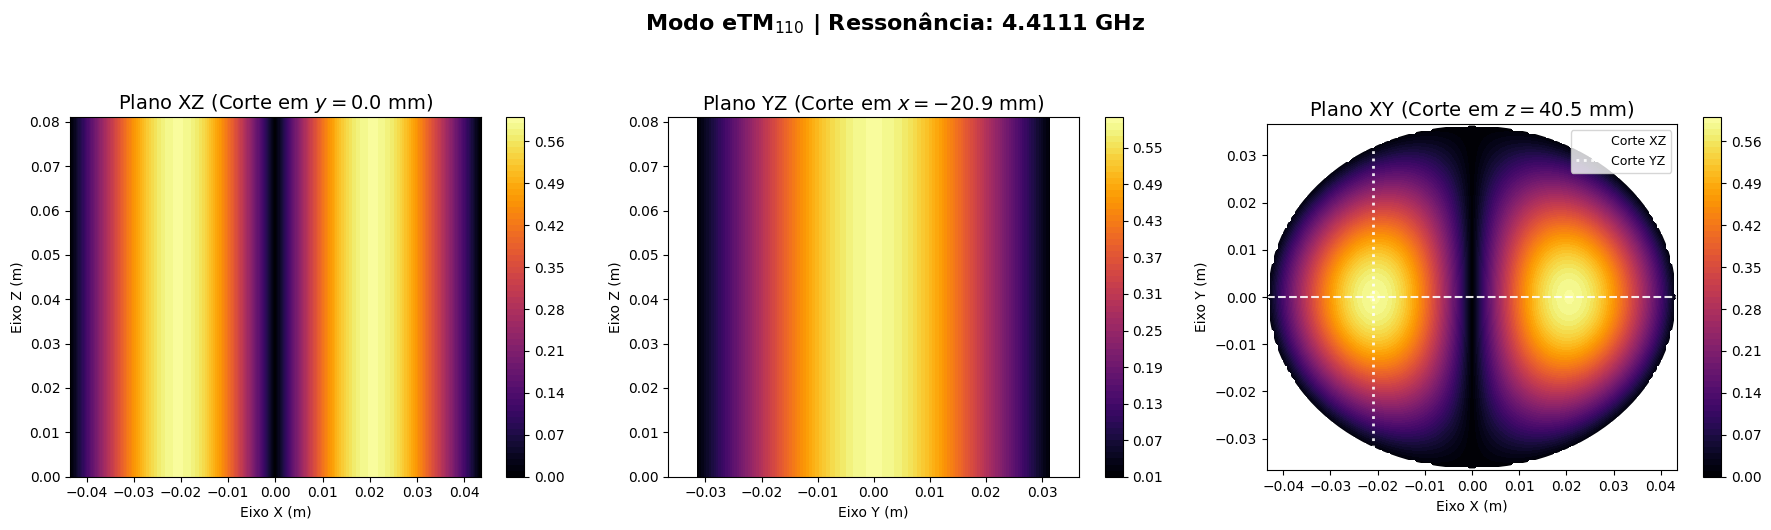

Gerando painel 1x3 para o Modo eTE_011...


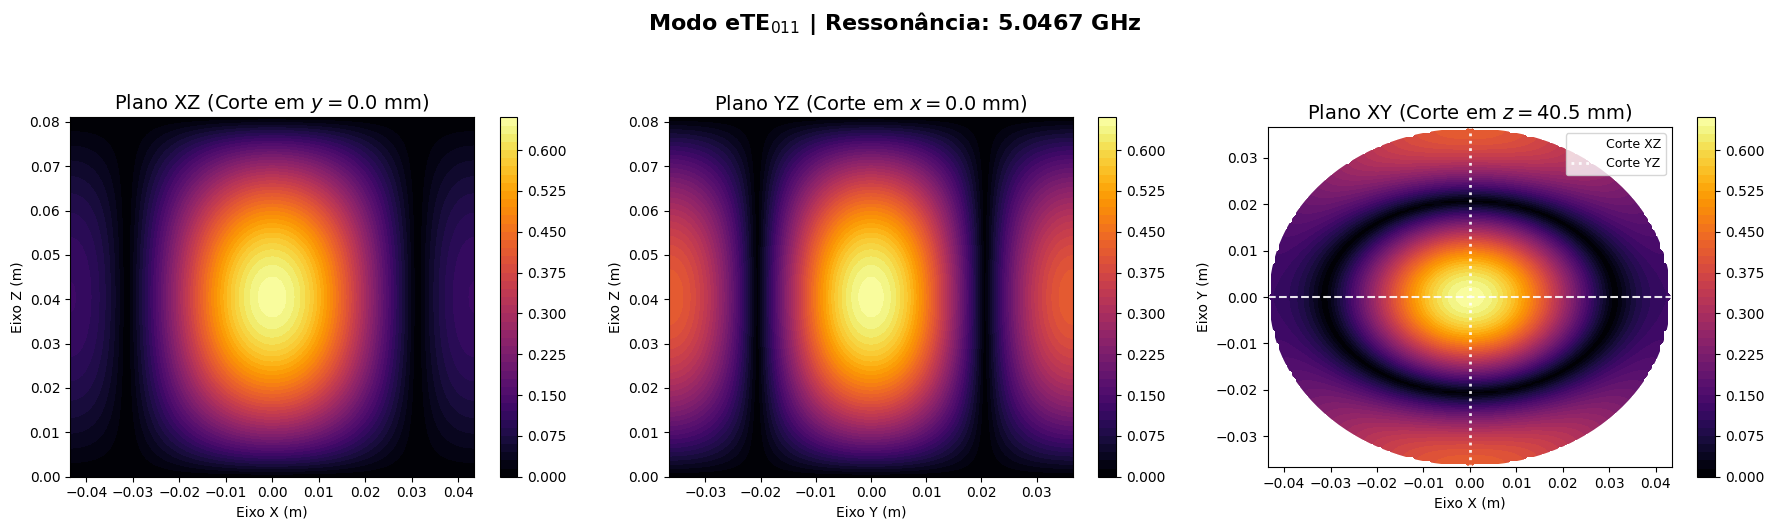

In [45]:
# Parâmetros convertidos para metros
a_mm = 43.50 * sc.milli  
b_mm = 36.61 * sc.milli  
d_mm = 81.00 * sc.milli  
er_val = 1.0  

cavidade_elip = CavidadeEliptica3D(a=a_mm, b=b_mm, d=d_mm, er=er_val)

# Exemplo 1: Modo eTM_110 (Equivalente aos dois lóbulos mostrados na sua imagem de referência)
print("Gerando painel 1x3 para o Modo eTM_110...")
plotar_planos_ortogonais(cavidade_elip, tipo_modo='TM', m=1, n=1, p=0)

# Exemplo 2: Modo eTE_111
print("Gerando painel 1x3 para o Modo eTE_011...")
plotar_planos_ortogonais(cavidade_elip, tipo_modo='TE', m=0, n=1, p=1)